# 01 — Data Collection
## TeleShift: Seasonal Comparison of Extreme Precipitation Synchronization Networks

This notebook documents the data collection process, verifies
that downloaded ERA5 files are complete and correctly formatted,
and prepares the data for network construction.

### Pipeline
1. Load raw ERA5 files (lazy, via dask)
2. Regrid from 0.25° to 1° resolution
3. Resave as contiguous unchunked files for fast access
4. Inspect and verify both datasets
5. Split into DJF and JJA seasons
6. Visual sanity check

Full data source documentation → `data/data_sources.md` <br>
Next step → `02_network_construction.ipynb`

## 1. Required Libraries

In [2]:
import os
import numpy as np
import xarray as xr
import netCDF4 as nc
import matplotlib.pyplot as plt
from dask.diagnostics import ProgressBar
import cartopy.crs as ccrs
import cartopy.feature as cfeature

## 2. File Paths

Raw ERA5 files are stored outside the project folder to avoid
OneDrive sync issues with large files. They are not tracked
by git. See `data/data_sources.md` for download instructions.

### File versions
| File | Resolution | Chunking | Used for |
|---|---|---|---|
| `*_raw.nc` | 0.25° | chunked | original CDS download |
| `*_1deg.nc` | 1° | chunked | intermediate regrid |
| `*_1deg_contiguous.nc` | 1° | contiguous | **all analysis** |

Only the contiguous files are used in this and all downstream notebooks.

In [3]:
# Raw file paths (0.25° resolution, original CDS downloads)
RAW_PRECIP = r'C:\Data\TeleShift\raw\era5_precip_1980_2026_DJF_JJA.nc'
RAW_Z500   = r'C:\Data\TeleShift\raw\era5_z500_1980_2026_DJF_JJA.nc'

# Intermediate regridded files (1° resolution, dask-chunked)
PRECIP_1DEG = r'C:\Data\TeleShift\raw\era5_precip_1980_2026_DJF_JJA_1deg.nc'
Z500_1DEG   = r'C:\Data\TeleShift\raw\era5_z500_1980_2026_DJF_JJA_1deg.nc'

# Final contiguous files — used for all analysis
PRECIP_CONTIGUOUS = r'C:\Data\TeleShift\raw\era5_precip_1980_2026_DJF_JJA_1deg_contiguous.nc'
Z500_CONTIGUOUS   = r'C:\Data\TeleShift\raw\era5_z500_1980_2026_DJF_JJA_1deg_contiguous.nc'

# ── Status check ───────────────────────────────────────────────
print('=== File Status ===')
all_files = [
    ('Raw Precipitation',        RAW_PRECIP),
    ('Raw Z500',                 RAW_Z500),
    ('Regridded Precipitation',  PRECIP_1DEG),
    ('Regridded Z500',           Z500_1DEG),
    ('Contiguous Precipitation', PRECIP_CONTIGUOUS),
    ('Contiguous Z500',          Z500_CONTIGUOUS),
]
for name, path in all_files:
    if os.path.exists(path):
        size = os.path.getsize(path) / (1024 ** 2)
        if size >= 1024:
            print(f'  ✓ {name}: {size/1024:.1f} GB')
        else:
            print(f'  ✓ {name}: {size:.1f} MB')
    else:
        print(f'  ○ {name}: not yet created')

=== File Status ===
  ✓ Raw Precipitation: 7.0 GB
  ✓ Raw Z500: 10.1 GB
  ✓ Regridded Precipitation: 951.4 MB
  ✓ Regridded Z500: 1.3 GB
  ✓ Contiguous Precipitation: 2.0 GB
  ✓ Contiguous Z500: 2.0 GB


## 3. Regrid Precipitation to 1°

The raw ERA5 precipitation file is at 0.25° resolution
(721 × 1440 grid), which is ~35 GB uncompressed.

We coarsen to 1° by averaging every 4×4 block of grid cells.
This 16× size reduction preserves all large-scale spatial
patterns relevant for teleconnection analysis.

Skipped if the regridded file already exists.

In [4]:
if not os.path.exists(PRECIP_1DEG):
    print('Loading raw precipitation file...')
    ds_precip_raw = xr.open_dataset(RAW_PRECIP, chunks={'valid_time': 100})
    print(f'Raw dimensions: {dict(ds_precip_raw.sizes)}')

    print('Regridding to 1°...')
    ds_precip_1deg = ds_precip_raw.coarsen(
        latitude=4, longitude=4, boundary='trim'
    ).mean()

    print('Saving regridded file...')
    with ProgressBar():
        ds_precip_1deg.to_netcdf(PRECIP_1DEG)
    print(f'Saved → {PRECIP_1DEG}')
else:
    print('Regridded precipitation file already exists — skipping.')

size_mb = os.path.getsize(PRECIP_1DEG) / (1024 ** 2)
print(f'File size: {size_mb:.1f} MB')

Regridded precipitation file already exists — skipping.
File size: 951.4 MB


## 4. Regrid Z500 to 1°

Same coarsening procedure applied to the geopotential dataset
for consistency with the precipitation grid.

Skipped if the regridded file already exists.

In [5]:
if not os.path.exists(Z500_1DEG):
    print('Loading raw Z500 file...')
    ds_z500_raw = xr.open_dataset(RAW_Z500, chunks={'valid_time': 100})
    print(f'Raw dimensions: {dict(ds_z500_raw.sizes)}')

    print('Regridding to 1°...')
    ds_z500_1deg = ds_z500_raw.coarsen(
        latitude=4, longitude=4, boundary='trim'
    ).mean()

    print('Saving regridded file...')
    with ProgressBar():
        ds_z500_1deg.to_netcdf(Z500_1DEG)
    print(f'Saved → {Z500_1DEG}')
else:
    print('Regridded Z500 file already exists — skipping.')

size_mb = os.path.getsize(Z500_1DEG) / (1024 ** 2)
print(f'File size: {size_mb:.1f} MB')

Regridded Z500 file already exists — skipping.
File size: 1349.0 MB


## 5. Save Contiguous Precipitation File

The regridded file was saved with dask chunks baked in
(chunk shape [1408, 30, 60]), which makes single-timestep
access very slow — numpy must reassemble hundreds of
non-contiguous blocks on every read.

We resave using netCDF4 directly with `contiguous=True`,
writing all data as a single sequential block on disk.
This makes array access ~100× faster.

Skipped if the contiguous file already exists.

In [6]:
if not os.path.exists(PRECIP_CONTIGUOUS):
    print('Saving contiguous precipitation file...')
    src = nc.Dataset(PRECIP_1DEG)
    dst = nc.Dataset(PRECIP_CONTIGUOUS, 'w')

    for name, dim in src.dimensions.items():
        dst.createDimension(name, len(dim))

    for name, var in src.variables.items():
        print(f'  Writing {name}...')
        dst_var = dst.createVariable(
            name, var.datatype, var.dimensions,
            contiguous=True
        )
        dst_var.setncatts({k: var.getncattr(k) for k in var.ncattrs()})
        dst_var[:] = var[:]

    dst.close()
    src.close()
    print(f'Saved → {PRECIP_CONTIGUOUS}')
else:
    print('Contiguous precipitation file already exists — skipping.')

# Verify
ds_check = nc.Dataset(PRECIP_CONTIGUOUS)
chunking = ds_check.variables['tp'].chunking()
ds_check.close()
size_mb = os.path.getsize(PRECIP_CONTIGUOUS) / (1024 ** 2)
print(f'File size : {size_mb:.1f} MB')
print(f'Chunking  : {chunking} — {"✓ contiguous" if chunking == "contiguous" else "✗ still chunked"}')

Contiguous precipitation file already exists — skipping.
File size : 2087.6 MB
Chunking  : contiguous — ✓ contiguous


## 6. Save Contiguous Z500 File

Same contiguous resave procedure applied to the Z500 dataset.

Skipped if the contiguous file already exists.

In [7]:
if not os.path.exists(Z500_CONTIGUOUS):
    print('Saving contiguous Z500 file...')
    src = nc.Dataset(Z500_1DEG)
    dst = nc.Dataset(Z500_CONTIGUOUS, 'w')

    for name, dim in src.dimensions.items():
        dst.createDimension(name, len(dim))

    for name, var in src.variables.items():
        print(f'  Writing {name}...')
        dst_var = dst.createVariable(
            name, var.datatype, var.dimensions,
            contiguous=True
        )
        dst_var.setncatts({k: var.getncattr(k) for k in var.ncattrs()})
        dst_var[:] = var[:]

    dst.close()
    src.close()
    print(f'Saved → {Z500_CONTIGUOUS}')
else:
    print('Contiguous Z500 file already exists — skipping.')

# Verify
ds_check = nc.Dataset(Z500_CONTIGUOUS)
chunking = ds_check.variables['z'].chunking()
ds_check.close()
size_mb = os.path.getsize(Z500_CONTIGUOUS) / (1024 ** 2)
print(f'File size : {size_mb:.1f} MB')
print(f'Chunking  : {chunking} — {"✓ contiguous" if chunking == "contiguous" else "✗ still chunked"}')

Contiguous Z500 file already exists — skipping.
File size : 2087.6 MB
Chunking  : contiguous — ✓ contiguous


## 7. Load Contiguous Files and Inspect

Load both contiguous files with xarray and verify dimensions,
time range, and spatial coverage. Also confirm that both
datasets share the same grid — a required check before
building any network.

In [8]:
ds_precip = xr.open_dataset(PRECIP_CONTIGUOUS)
ds_z500   = xr.open_dataset(Z500_CONTIGUOUS)

print('=== Precipitation (contiguous) ===')
print(f'Dimensions : {dict(ds_precip.sizes)}')
print(f'Time range : {str(ds_precip.valid_time.values[0])[:10]} → '
      f'{str(ds_precip.valid_time.values[-1])[:10]}')
print(f'Lat range  : {float(ds_precip.latitude.min()):.2f} → '
      f'{float(ds_precip.latitude.max()):.2f}')
print(f'Lon range  : {float(ds_precip.longitude.min()):.2f} → '
      f'{float(ds_precip.longitude.max()):.2f}')
print(f'Variable   : {list(ds_precip.data_vars)}')

print()

print('=== Z500 (contiguous) ===')
print(f'Dimensions : {dict(ds_z500.sizes)}')
print(f'Time range : {str(ds_z500.valid_time.values[0])[:10]} → '
      f'{str(ds_z500.valid_time.values[-1])[:10]}')
print(f'Lat range  : {float(ds_z500.latitude.min()):.2f} → '
      f'{float(ds_z500.latitude.max()):.2f}')
print(f'Lon range  : {float(ds_z500.longitude.min()):.2f} → '
      f'{float(ds_z500.longitude.max()):.2f}')
print(f'Variable   : {list(ds_z500.data_vars)}')

print()

# Grid consistency check
grids_match = (
    len(ds_precip.latitude)   == len(ds_z500.latitude)   and
    len(ds_precip.longitude)  == len(ds_z500.longitude)  and
    len(ds_precip.valid_time) == len(ds_z500.valid_time)
)
print(f'Grids match: {"✓ YES" if grids_match else "✗ NO — investigate before proceeding"}')

=== Precipitation (contiguous) ===
Dimensions : {'valid_time': 8443, 'latitude': 180, 'longitude': 360}
Time range : 1980-01-01 → 2026-02-28
Lat range  : -89.38 → 89.62
Lon range  : 0.38 → 359.38
Variable   : ['tp']

=== Z500 (contiguous) ===
Dimensions : {'valid_time': 8443, 'pressure_level': 1, 'latitude': 180, 'longitude': 360}
Time range : 1980-01-01 → 2026-02-28
Lat range  : -89.38 → 89.62
Lon range  : 0.38 → 359.38
Variable   : ['z']

Grids match: ✓ YES


## 8. Seasonal Split

Separate the precipitation dataset into two seasonal subsets:

- **DJF** — December, January, February (boreal winter)
- **JJA** — June, July, August (boreal summer)

These two subsets are the direct inputs to the network
construction pipeline in notebook 02.

In [9]:
djf = ds_precip.sel(valid_time=ds_precip.valid_time.dt.month.isin([12, 1, 2]))
jja = ds_precip.sel(valid_time=ds_precip.valid_time.dt.month.isin([6, 7, 8]))

print(f'DJF time steps : {len(djf.valid_time)}')
print(f'JJA time steps : {len(jja.valid_time)}')
print(f'Total          : {len(djf.valid_time) + len(jja.valid_time)}')
print(f'Expected total : {len(ds_precip.valid_time)}')

DJF time steps : 4211
JJA time steps : 4232
Total          : 8443
Expected total : 8443


## 9. Visual Check — DJF vs JJA Mean Precipitation

Side-by-side comparison of mean daily precipitation in each
season across the full 1980–2026 period.

This is a first sanity check for **H2** — we expect visibly
different spatial patterns between the two seasons:
- **JJA:** Strong signal over tropical monsoon regions
  (South Asia, West Africa, Central America)
- **DJF:** Stronger signal over extratropical regions
  and the southern hemisphere tropics

With the contiguous file this cell runs in under one minute.

Computing DJF mean...
Done. Shape: (180, 360)
Computing JJA mean...
Done. Shape: (180, 360)
Plotting...


c:\Users\erenk\AppData\Local\Programs\Python\Python311\Lib\site-packages\cartopy\io\__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
c:\Users\erenk\AppData\Local\Programs\Python\Python311\Lib\site-packages\cartopy\io\__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


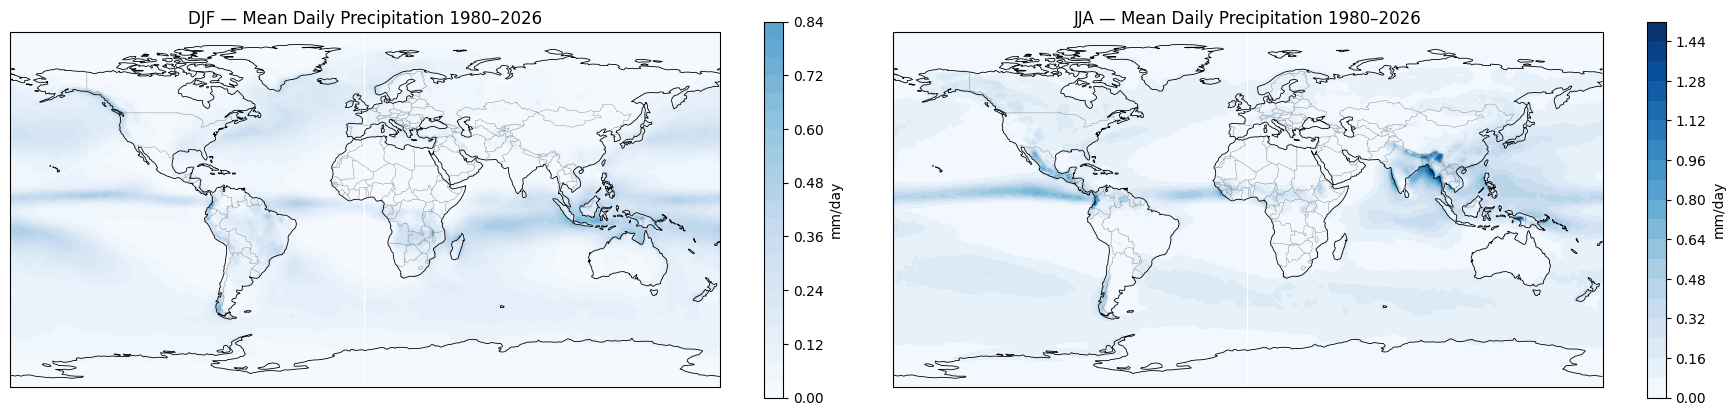

Saved → figures/01_djf_vs_jja_mean_precipitation.png


In [10]:
os.makedirs('../figures', exist_ok=True)

print('Computing DJF mean...')
djf_mean = djf['tp'].values.mean(axis=0) * 1000  # m → mm
print(f'Done. Shape: {djf_mean.shape}')

print('Computing JJA mean...')
jja_mean = jja['tp'].values.mean(axis=0) * 1000
print(f'Done. Shape: {jja_mean.shape}')

print('Plotting...')
vmax = max(djf_mean.max(), jja_mean.max())
lats = ds_precip.latitude.values
lons = ds_precip.longitude.values

fig, axes = plt.subplots(
    1, 2, figsize=(18, 5),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

for ax, data, title in zip(
    axes,
    [djf_mean, jja_mean],
    ['DJF — Mean Daily Precipitation 1980–2026',
     'JJA — Mean Daily Precipitation 1980–2026']
):
    im = ax.contourf(
        lons, lats, data,
        cmap='Blues', levels=20,
        vmin=0, vmax=vmax,
        transform=ccrs.PlateCarree()
    )
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6, edgecolor='black')
    ax.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor='gray')
    ax.set_global()
    ax.set_title(title)
    plt.colorbar(im, ax=ax, label='mm/day', shrink=0.8)

plt.tight_layout()
plt.savefig('../figures/01_djf_vs_jja_mean_precipitation.png', dpi=150)
plt.show()
print('Saved → figures/01_djf_vs_jja_mean_precipitation.png')

## 9b. Visual Check — Evaluation

The maps confirm our expectations for **H2**:

**JJA (boreal summer):**
- The Indian monsoon dominates as the strongest signal in the
  entire dataset — deep blue over Bangladesh, northeastern India,
  and the Bay of Bengal
- West African monsoon visible as a precipitation band along
  the Gulf of Guinea coast (~10°N)
- Moderate signal over Central America and the Caribbean,
  consistent with the northward ITCZ position in boreal summer

**DJF (boreal winter):**
- The Maritime Continent (Indonesia, Philippines) dominates —
  this is the southern hemisphere ITCZ during austral summer
- Southern hemisphere tropics show clear activity over Brazil,
  central Africa, and northern Australia — regions quiet in JJA
- Mid-latitude storm tracks subtly visible as diffuse blue bands,
  slightly stronger than in JJA

**Note on color scales:** The two panels use different scales
(JJA max 1.44 mm/day vs DJF max 0.84 mm/day). JJA has more
intense precipitation overall, but our network analysis measures
spatial synchronization between locations — not raw intensity.
The different scales do not affect the network construction.

**Preliminary verdict:** Spatial patterns are clearly distinct
between seasons even before any network is built — a strong
visual indicator that H2 is worth testing.

## 10. Summary

| Check | Description | Status |
|---|---|---|
| Raw files present | Both .nc files found at data path | ✓ |
| Regridding complete | 0.25° → 1° coarsening applied | ✓ |
| Contiguous files saved | Fast sequential disk access verified | ✓ |
| Grid consistency | Precip and Z500 share same grid | ✓ |
| Seasonal split | DJF and JJA subsets created | ✓ |
| Visual check | Seasonal contrast visible in mean maps | ✓ |

### Files used in downstream notebooks
| Variable | File |
|---|---|
| Precipitation | `era5_precip_1980_2026_DJF_JJA_1deg_contiguous.nc` |
| Geopotential | `era5_z500_1980_2026_DJF_JJA_1deg_contiguous.nc` |

Data is verified and ready for network construction. <br>
Proceed to `02_network_construction.ipynb`.